In [28]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi 
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [29]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [30]:
modeApi = lumapi.MODE(hide = False)

## units
um = 1e-6
nm = 1e-9

#wavelength

wavelength = 1550 * nm
start_wavelength = 1500 * nm
stop_wavelength = 1600 * nm

## Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

## Dimensions

wvg_width = 450 * nm
wvg_height = 220 * nm
wvg_length = 3*um
WM = 7 * um
taper_length = 15 * um
taper_max_height = 1.5 * um

n_c = 1.5 # Refractive index of cladding
n_r = 3.5 # Refractive index of core
sigma = 0 # Conductivity of core
N = 2 # Number of desired imagens in the output

n_eff_array = np.loadtxt('neff_core.txt') # Exporting the effective index of the modes
beta_array = (2*np.pi/wavelength)*n_eff_array

We = WM + (wavelength / np.pi) * np.power(n_c / n_r,  2*sigma) * np.power(n_r**2 - n_c**2, -0.5)

In [31]:
n_c = 1.5 # Refractive index of cladding
n_r = 3.5 # Refractive index of core
sigma = 0 # Conductivity of core
N = 2 # Number of desired imagens in the output

n_eff_array = np.loadtxt('neff_core.txt') # Exporting the effective index of the modes
beta_array = (2*np.pi/wavelength)*n_eff_array

L_pi = np.pi / (beta_array[0] - beta_array[1])
We = WM + (wavelength / np.pi) * np.power(n_c / n_r,  2*sigma) * np.power(n_r**2 - n_c**2, -0.5)

L = 3*L_pi/(N)

print('\033[1mComprimento do dispositivo: %.2f \u03BCm' %(L/um))
print('Largura efetiva do dispositivo: %.2f \u03BCm' %(We/um))

Comprimento do dispositivo: 181.05 μm
Largura efetiva do dispositivo: 7.16 μm


## Construção do dispositivo ##

In [32]:
modeApi.addrect()
modeApi.set('name', 'central box')
modeApi.set('x', 0)
modeApi.set('x span', L)
modeApi.set('y', 0)
modeApi.set('y span', WM)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

x_tapers = [(L+taper_length)/2, (L+taper_length)/2, -(L+taper_length)/2, -(L+taper_length)/2]
y_tapers = [We/6, -We/6, We/6, -We/6]
width_l_tapers = [taper_max_height, taper_max_height, wvg_width, wvg_width]
width_r_tapers = [wvg_width, wvg_width, taper_max_height, taper_max_height]

for i in range(0,4,1):
    modeApi.addobject('linear_taper')
    modeApi.set('name', 'taper_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('len', taper_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('width_l', width_l_tapers[i])
    modeApi.set('width_r', width_r_tapers[i])
    modeApi.set('z', 0)
    modeApi.set('thickness', wvg_height)
    modeApi.set('angle_side', 90)
    modeApi.set('material', material)

x_guias = [(L+2*taper_length+wvg_length)/2, (L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2]

for i in range(0,4,1):
    modeApi.addrect()
    modeApi.set('name', 'wvg_%d' %(i+1))
    modeApi.set('x', x_guias[i])
    modeApi.set('x span', wvg_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', wvg_width)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('material', material)

## Definindo o solver EME ##

In [33]:
## add solver

modeApi.addeme()

bound_x_offset = 0.5*um
bound_y_offset = 2*um
bound_z_offset = 0.5*um

port_y_span = 1*um
port_z_span = 1*um

## Dimensions
modeApi.set('x',0)
modeApi.set('x min', -(L/2 + taper_length + wvg_length))
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span + 2*bound_z_offset)

## Banckground material
modeApi.set('background material', sub_material)

##add meshs

for i in range(0,4,1):
    modeApi.addmesh()
    modeApi.set('set mesh multiplier', True)
    modeApi.set('name', 'mesh_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('x span', taper_length)
    modeApi.set('x mesh multiplier', 2)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', taper_max_height)
    modeApi.set('y mesh multiplier', 2)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('z mesh multiplier', 2)

In [34]:
## Set cell properties
cell_wvg = 1
cell_taper = 16
cell_box = 1

span_wvg = wvg_length
span_taper = taper_length
span_box = L

method_wvg = 0 # 0 -> none, 1 -> CVCS
method_taper = 1
method_box = 0

modes_wvg = 4
modes_taper = 10
modes_box = 30

modeApi.select('EME')
modeApi.set('number of cell groups', 5)
modeApi.set('group spans', np.block([[span_wvg], [span_taper], [span_box], [span_taper], [span_wvg]]))
modeApi.set('cells', np.block([[cell_wvg], [cell_taper], [cell_box], [cell_taper], [cell_wvg]]))
modeApi.set('subcell method', np.block([[method_wvg], [method_taper], [method_box], [method_taper], [method_wvg]]))
modeApi.set('allow custom eigensolver settings', True)
modeApi.set('modes', np.block([[modes_wvg], [modes_taper], [modes_box], [modes_taper], [modes_wvg]]))
modeApi.set('display cells', 1)

## Number os mesh cells without override regions
modeApi.set('mesh cells y',200)
modeApi.set('mesh cells z',200)

## Boundary conditions
modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')
modeApi.set('z min bc', 'Symmetric')
modeApi.set('z max bc', 'PML')

In [35]:
modeApi.select('EME::Ports::port_1')
modeApi.set('use full simulation span', 0)
modeApi.set('y', We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.select('EME::Ports::port_2')
modeApi.set('use full simulation span', 0)
modeApi.set('y', We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'left')
modeApi.set('y', -We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'right')
modeApi.set('y', -We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

In [36]:
eme_x_span = modeApi.getnamed('EME', 'x span')
print('\033[1mComprimento do solver: %.2f \u03BCm' %(eme_x_span/um))

Comprimento do solver: 217.05 μm


In [37]:
## add monitor
modeApi.addemeprofile()
modeApi.set('name', 'profile')
modeApi.set('monitor type', 3) #2D Z normal
modeApi.set('x', 0)
modeApi.set('x span', eme_x_span+ bound_x_offset*2)
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)

## Otimização em relação a posição das portas ##

In [38]:
y_tapers_array = np.linspace(taper_max_height/2,3.5*um-taper_max_height/2,11)
transmissao_array = np.zeros(len(y_tapers_array))
modeApi.save('MMI_EME.lmp')

for i in range(0,len(y_tapers_array),1):
    modeApi.switchtolayout()
    for j in range(0,3,2):
        modeApi.select('taper_%d' %(j+1))
        modeApi.set('y', y_tapers_array[i])
        modeApi.select('taper_%d' %(j+2))
        modeApi.set('y', -y_tapers_array[i])
        modeApi.select('wvg_%d' %(j+1))
        modeApi.set('y', y_tapers_array[i])
        modeApi.select('wvg_%d' %(j+2))
        modeApi.set('y', -y_tapers_array[i])
        modeApi.select('mesh_%d' %(j+1))
        modeApi.set('y', y_tapers_array[i])
        modeApi.select('mesh_%d' %(j+2))
        modeApi.set('y', -y_tapers_array[i])
    modeApi.select('EME::Ports::port_1')
    modeApi.set('y', y_tapers_array[i])
    modeApi.select('EME::Ports::port_2')
    modeApi.set('y', y_tapers_array[i])
    modeApi.select('EME::Ports::port_3')
    modeApi.set('y', -y_tapers_array[i])
    modeApi.select('EME::Ports::port_4')
    modeApi.set('y', -y_tapers_array[i])


    modeApi.run()

    modeApi.setemeanalysis('wavelength sweep', 1)
    modeApi.setemeanalysis('start wavelength', start_wavelength)
    modeApi.setemeanalysis('stop wavelength', stop_wavelength)
    modeApi.setemeanalysis('number of wavelength points', 11)
    modeApi.setemeanalysis('calculate group delays', 1)
    
    modeApi.emesweep('wavelength sweep')
    S = modeApi.getemesweep('S_wavelength_sweep')
    if i == 0: # Para não acessar S['wavelength'] todas as vezes
        wavelength_array = S['wavelength']
        

    transmissao_array[i] = (np.abs(S['s31'])**2)[5] + (np.abs(S['s41'])**2)[5]  # In the S-matrix index mapping, the second port stay in index 3, for some reason

In [ ]:
print(wavelength_array[5])

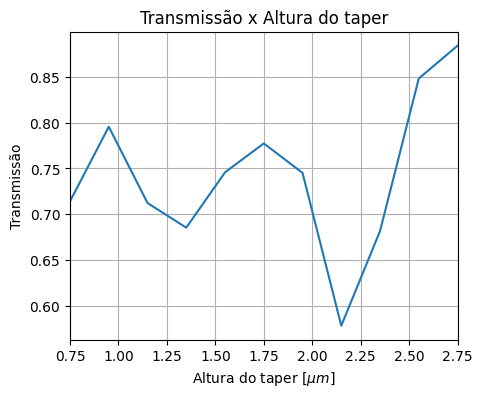

In [39]:
fig2 = plt.figure(figsize=(5,4))

plt.plot(y_tapers_array/um, transmissao_array, linewidth=1.5)
plt.grid(True)
plt.xlabel(r'Altura do taper [$\mu m$]')
plt.xlim(y_tapers_array[0]/um, y_tapers_array[-1]/um)
plt.ylabel('Transmissão')
plt.title('Transmissão x Altura do taper')

plt.show()

In [40]:
best_position = np.argmax(transmissao_array)
best_position

np.int64(10)

### Comportamento do dispositivo com as portas otimizadas ##

In [41]:
modeApi.close()
modeApi = lumapi.MODE(hide=False)

In [ ]:
## Reconstruindo o dispositivo
modeApi.addrect()
modeApi.set('name', 'central box')
modeApi.set('x', 0)
modeApi.set('x span', L)
modeApi.set('y', 0)
modeApi.set('y span', WM)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

x_tapers = [(L+taper_length)/2, (L+taper_length)/2, -(L+taper_length)/2, -(L+taper_length)/2]
y_tapers = [y_tapers_array[best_position], -y_tapers_array[best_position], y_tapers_array[best_position], -y_tapers_array[best_position]]
width_l_tapers = [taper_max_height, taper_max_height, wvg_width, wvg_width]
width_r_tapers = [wvg_width, wvg_width, taper_max_height, taper_max_height]

for i in range(0,4,1):
    modeApi.addobject('linear_taper')
    modeApi.set('name', 'taper_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('len', taper_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('width_l', width_l_tapers[i])
    modeApi.set('width_r', width_r_tapers[i])
    modeApi.set('z', 0)
    modeApi.set('thickness', wvg_height)
    modeApi.set('angle_side', 90)
    modeApi.set('material', material)

x_guias = [(L+2*taper_length+wvg_length)/2, (L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2]

for i in range(0,4,1):
    modeApi.addrect()
    modeApi.set('name', 'wvg_%d' %(i+1))
    modeApi.set('x', x_guias[i])
    modeApi.set('x span', wvg_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', wvg_width)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('material', material)

In [43]:
## add solver

modeApi.addeme()

bound_x_offset = 0.5*um
bound_y_offset = 2*um
bound_z_offset = 0.5*um

port_y_span = 1*um
port_z_span = 1*um

## Dimensions
modeApi.set('x',0)
modeApi.set('x min', -(L/2 + taper_length + wvg_length))
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span + 2*bound_z_offset)

## Banckground material
modeApi.set('background material', sub_material)

##add meshs

for i in range(0,4,1):
    modeApi.addmesh()
    modeApi.set('set mesh multiplier', True)
    modeApi.set('name', 'mesh_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('x span', taper_length)
    modeApi.set('x mesh multiplier', 2)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', taper_max_height)
    modeApi.set('y mesh multiplier', 2)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('z mesh multiplier', 2)

In [44]:
## Set cell properties
cell_wvg = 1
cell_taper = 16
cell_box = 1

span_wvg = wvg_length
span_taper = taper_length
span_box = L

method_wvg = 0 # 0 -> none, 1 -> CVCS
method_taper = 1
method_box = 0

modes_wvg = 4
modes_taper = 10
modes_box = 30

modeApi.select('EME')
modeApi.set('number of cell groups', 5)
modeApi.set('group spans', np.block([[span_wvg], [span_taper], [span_box], [span_taper], [span_wvg]]))
modeApi.set('cells', np.block([[cell_wvg], [cell_taper], [cell_box], [cell_taper], [cell_wvg]]))
modeApi.set('subcell method', np.block([[method_wvg], [method_taper], [method_box], [method_taper], [method_wvg]]))
modeApi.set('allow custom eigensolver settings', True)
modeApi.set('modes', np.block([[modes_wvg], [modes_taper], [modes_box], [modes_taper], [modes_wvg]]))
modeApi.set('display cells', 1)

## Number os mesh cells without override regions
modeApi.set('mesh cells y',200)
modeApi.set('mesh cells z',200)

## Boundary conditions
modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')
modeApi.set('z min bc', 'Symmetric')
modeApi.set('z max bc', 'PML')

In [ ]:
modeApi.select('EME::Ports::port_1')
modeApi.set('use full simulation span', 0)
modeApi.set('y', y_tapers_array[best_position])
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.select('EME::Ports::port_2')
modeApi.set('use full simulation span', 0)
modeApi.set('y', y_tapers_array[best_position])
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'left')
modeApi.set('y', -y_tapers_array[best_position])
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'right')
modeApi.set('y', -y_tapers_array[best_position])
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

In [46]:
eme_x_span = modeApi.getnamed('EME', 'x span')
print('\033[1mComprimento do solver: %.2f \u03BCm' %(eme_x_span/um))

Comprimento do solver: 217.05 μm


In [47]:
## add monitor
modeApi.addemeprofile()
modeApi.set('name', 'profile')
modeApi.set('monitor type', 3)
modeApi.set('x', 0)
modeApi.set('x span', eme_x_span+ bound_x_offset*2)
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)

In [49]:
modeApi.save('MMI_EME.lmp')
modeApi.run()

In [50]:
modeApi.emepropagate()

In [51]:
eField = modeApi.getresult('profile', 'field profile')

x = eField['x']
x = x[:,0]/um
y = eField['y']
y = y[:,0]/um
z = eField['z']
eField = eField['E']

Ex = eField[:,:, 0,:,0]
Ey = eField[:,:, 0,:,1]
Ez = eField[:,:, 0,:,2]

E = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2)

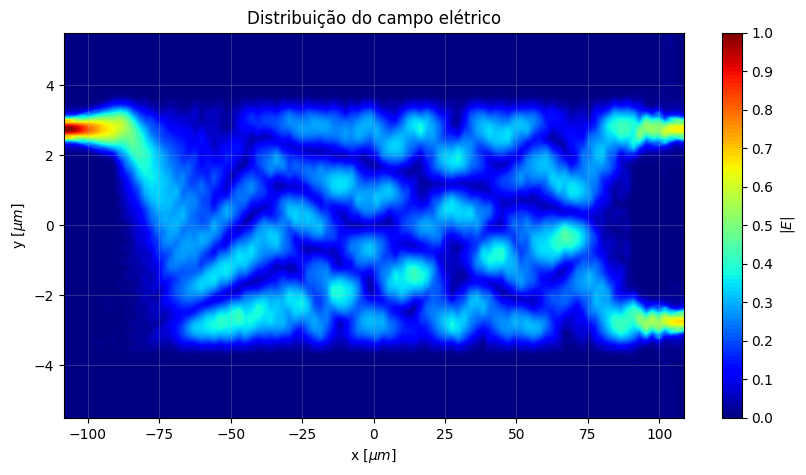

In [52]:
plt.figure(figsize=(10,5))

v = np.linspace(0, 1, 101)

plt.contourf(x,y,np.transpose(E[:,:,0]), v, cmap = plt.get_cmap('jet'))
plt.colorbar(ticks = np.linspace(0, 1, 11), label = r'$|E|$')

plt.title('Distribuição do campo elétrico')
plt.ylabel(r'y [$\mu m$]')
plt.xlabel(r'x [$\mu m$]')
plt.grid(True, alpha = 0.25)

plt.show()

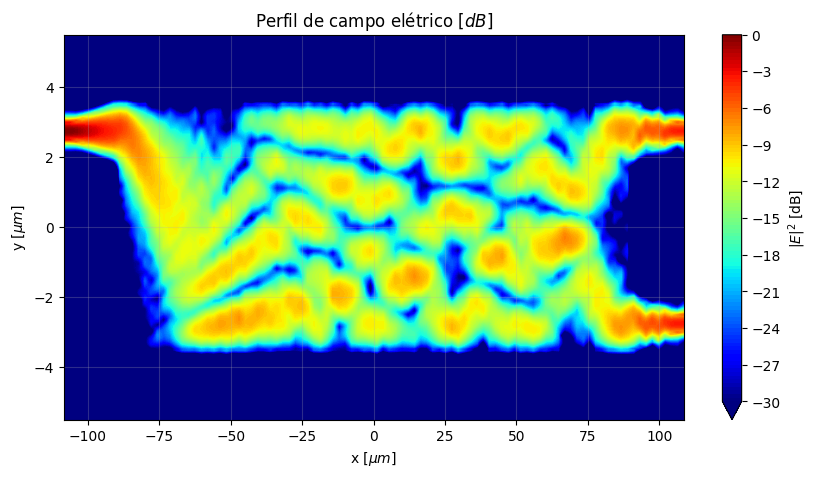

In [73]:
E2 = np.power(E[:,:,0],2)
E2_dB = 10*np.log10(E2/np.max(E2))

v_dB = np.linspace(-30, 0, 101)

plt.figure(figsize=(10,5))
plt.contourf(x,y,np.transpose(E2_dB), v_dB, cmap = plt.get_cmap('jet'), extend = 'min')
plt.colorbar(ticks = np.linspace(-30, 0, 11), label = r'$|E|^2$ [dB]')

plt.title('Perfil de campo elétrico [$dB$]')
plt.ylabel(r'y [$\mu m$]')
plt.xlabel(r'x [$\mu m$]')
plt.grid(True, alpha = 0.25)

plt.show()

In [54]:
modeApi.setemeanalysis('wavelength sweep', 1)
modeApi.setemeanalysis('start wavelength', start_wavelength)
modeApi.setemeanalysis('stop wavelength', stop_wavelength)
modeApi.setemeanalysis('number of wavelength points', 11)
modeApi.setemeanalysis('calculate group delays', 1)

In [55]:
modeApi.emesweep('wavelength sweep')
S = modeApi.getemesweep('S_wavelength_sweep')
wavelength_array = S['wavelength']

T1 = np.abs(S['s11'])**2
T2 = np.abs(S['s31'])**2 # In the S-matrix index mapping, the second port stay in index 3, for some reason
T3 = np.abs(S['s21'])**2 # The third port stay in index 2
T4 = np.abs(S['s41'])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

Text(0.5, 1.0, 'Transmitância [$dB$] x Comprimento de onda')

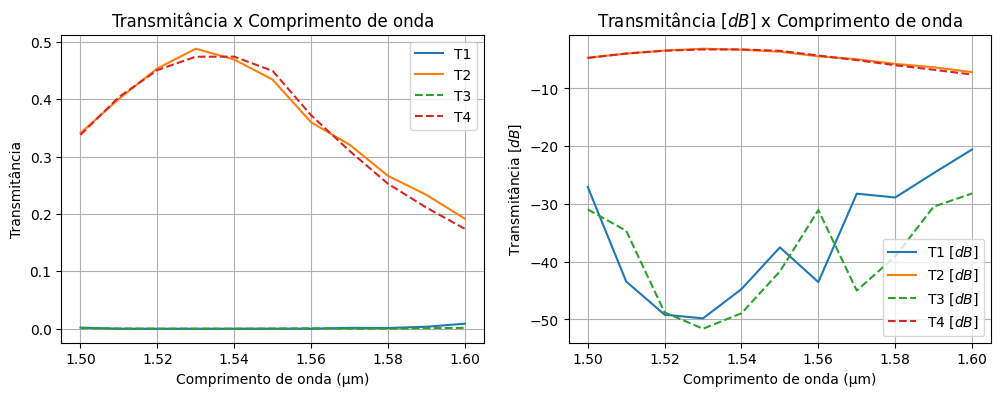

In [56]:
fig4, axs4 = plt.subplots(1, 2, figsize=(12, 4))

axs4[0].plot(wavelength_array/um, T1, label='T1', linewidth=1.5)
axs4[0].plot(wavelength_array/um, T2, label='T2', linewidth=1.5)
axs4[0].plot(wavelength_array/um, T3, label='T3', linewidth=1.5, linestyle='--')
axs4[0].plot(wavelength_array/um, T4, label='T4', linewidth=1.5, linestyle='--')
axs4[0].legend(loc='best')
axs4[0].grid()
axs4[0].set_xlabel('Comprimento de onda (\u03BCm)')
axs4[0].set_ylabel('Transmitância')
axs4[0].set_title('Transmitância x Comprimento de onda')

axs4[1].plot(wavelength_array/um, T1_dB, label = 'T1 [$dB$]', linewidth = 1.5)
axs4[1].plot(wavelength_array/um, T2_dB, label='T2 [$dB$]', linewidth=1.5)
axs4[1].plot(wavelength_array/um, T3_dB, label='T3 [$dB$]', linewidth=1.5, linestyle = '--')
axs4[1].plot(wavelength_array/um, T4_dB, label='T4 [$dB$]', linewidth=1.5, linestyle = '--')
axs4[1].legend(loc='best')
axs4[1].grid()
axs4[1].set_xlabel('Comprimento de onda (\u03BCm)')
axs4[1].set_ylabel(r'Transmitância [$dB$]')
#axs4[1].set_ylim([0,0.5])
axs4[1].set_title(r'Transmitância [$dB$] x Comprimento de onda')

In [57]:
total_transmission = T2 + T4
toytal_transmission_dB = 10*np.log10(total_transmission)

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento de onda')

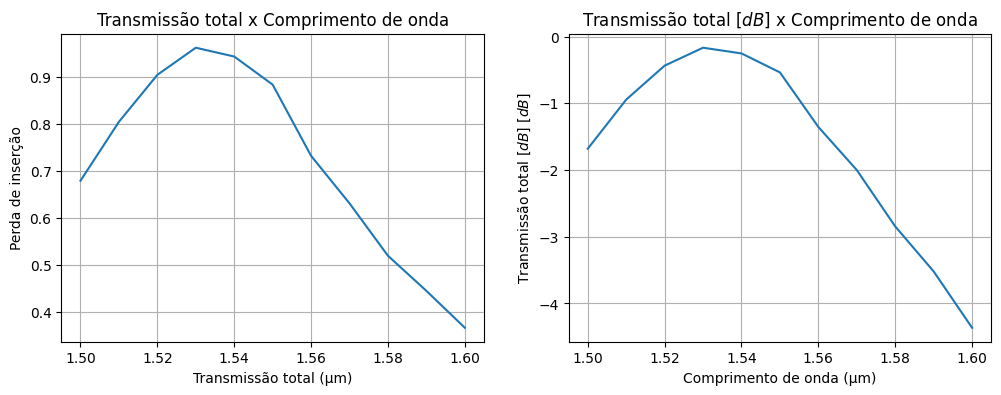

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(wavelength_array/um, total_transmission, linewidth=1.5)
axs[0].grid(True)
axs[0].set_xlabel('Transmissão total (\u03BCm)')
axs[0].set_ylabel('Perda de inserção')
axs[0].set_title('Transmissão total x Comprimento de onda')

axs[1].plot(wavelength_array/um, toytal_transmission_dB, linewidth = 1.5)
axs[1].grid(True)
axs[1].set_xlabel('Comprimento de onda (\u03BCm)')
axs[1].set_ylabel(r'Transmissão total [$dB$] [$dB$]')
axs[1].set_title(r'Transmissão total [$dB$] x Comprimento de onda')

## Otimização em relação ao comprimento do guia central ##

In [59]:
modeApi.setemeanalysis('propagation sweep', 1)
modeApi.setemeanalysis('parameter', 'group span 3')
modeApi.setemeanalysis('start', 0.4*span_box)
modeApi.setemeanalysis('stop', 1.6*span_box)
modeApi.setemeanalysis('number of points', 101)

In [60]:
modeApi.emesweep('propagation sweep')

In [63]:
S = modeApi.getemesweep('S')
group_span = S['group_span_3']

T1 = (np.abs(S['s11'])**2)
T2 = (np.abs(S['s31'])**2) # In the S-matrix index mapping, the second port stay in index 3, for some reason
T3 = (np.abs(S['s21'])**2) # The third port stay in index 2
T4 = (np.abs(S['s41'])**2)

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

Text(0.5, 1.0, 'Transmitância [$dB$] x Comprimento da caixa central')

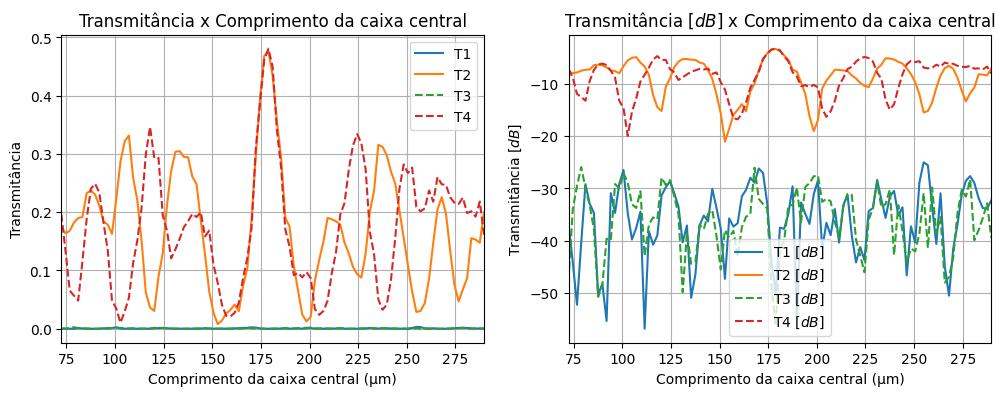

In [74]:
fig2, axs2 = plt.subplots(1,2, figsize=(12,4))

axs2[0].plot(group_span/um, T1, label='T1', linewidth=1.5)
axs2[0].plot(group_span/um, T2, label='T2', linewidth=1.5)
axs2[0].plot(group_span/um, T3, label='T3', linewidth=1.5, linestyle='--')
axs2[0].plot(group_span/um, T4, label='T4', linewidth=1.5, linestyle='--')
axs2[0].legend(loc='best')
axs2[0].grid()
axs2[0].set_xlabel('Comprimento da caixa central (\u03BCm)')
axs2[0].set_ylabel('Transmitância')
axs2[0].set_xlim([0.4*span_box/um,1.6*span_box/um])
#axs2[0].set_ylim([0,0.5])
axs2[0].set_title('Transmitância x Comprimento da caixa central')
#axs2[0].plot([178.5,178.5], [0,0.5], 'black', linewidth = 1.5, linestyle = '--')

axs2[1].plot(group_span/um, T1_dB, label = 'T1 [$dB$]', linewidth = 1.5)
axs2[1].plot(group_span/um, T2_dB, label='T2 [$dB$]', linewidth=1.5)
axs2[1].plot(group_span/um, T3_dB, label='T3 [$dB$]', linewidth=1.5, linestyle = '--')
axs2[1].plot(group_span/um, T4_dB, label='T4 [$dB$]', linewidth=1.5, linestyle = '--')
axs2[1].legend(loc='best')
axs2[1].grid()
axs2[1].set_xlabel('Comprimento da caixa central (\u03BCm)')
axs2[1].set_ylabel('Transmitância [$dB$]')
axs2[1].set_xlim([0.4*span_box/um,1.6*span_box/um])
#axs2[1].set_ylim([0,0.5])
axs2[1].set_title('Transmitância [$dB$] x Comprimento da caixa central')

In [75]:
print('\033[1mComprimento da caixa central para uma divisão igualitária entre as portas de saída: %.1f \u03BCm\033[0m' %(178.5))

Comprimento da caixa central para uma divisão igualitária entre as portas de saída: 178.5 μm


In [76]:
total_transmission = T2 + T4
toytal_transmission_dB = 10*np.log10(total_transmission)

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento da caixa central')

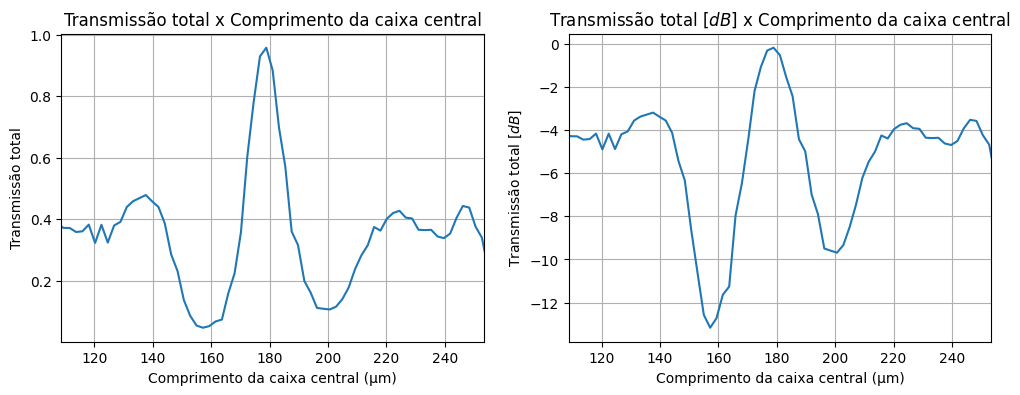

In [78]:
fig3, axs3 = plt.subplots(1,2, figsize=(12,4))

axs3[0].plot(group_span/um, total_transmission, linewidth=1.5)
axs3[0].grid()
axs3[0].set_xlabel('Comprimento da caixa central (\u03BCm)')
axs3[0].set_ylabel('Transmissão total')
axs3[0].set_xlim([0.6*span_box/um,1.4*span_box/um])
axs3[0].set_title('Transmissão total x Comprimento da caixa central')

axs3[1].plot(group_span/um, toytal_transmission_dB, linewidth=1.5)
axs3[1].grid()
axs3[1].set_xlabel('Comprimento da caixa central (\u03BCm)')
axs3[1].set_ylabel(r'Transmissão total [$dB$]')
axs3[1].set_xlim([0.6*span_box/um,1.4*span_box/um])
axs3[1].set_title(r'Transmissão total [$dB$] x Comprimento da caixa central')

In [81]:
modeApi.close()
modeApi = lumapi.MODE(hide=False)

L = 178.5*um

In [82]:
modeApi.addrect()
modeApi.set('name', 'central box')
modeApi.set('x', 0)
modeApi.set('x span', L)
modeApi.set('y', 0)
modeApi.set('y span', WM)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

x_tapers = [(L+taper_length)/2, (L+taper_length)/2, -(L+taper_length)/2, -(L+taper_length)/2]
y_tapers = [We/6, -We/6, We/6, -We/6]
width_l_tapers = [taper_max_height, taper_max_height, wvg_width, wvg_width]
width_r_tapers = [wvg_width, wvg_width, taper_max_height, taper_max_height]

for i in range(0,4,1):
    modeApi.addobject('linear_taper')
    modeApi.set('name', 'taper_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('len', taper_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('width_l', width_l_tapers[i])
    modeApi.set('width_r', width_r_tapers[i])
    modeApi.set('z', 0)
    modeApi.set('thickness', wvg_height)
    modeApi.set('angle_side', 90)
    modeApi.set('material', material)

x_guias = [(L+2*taper_length+wvg_length)/2, (L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2, -(L+2*taper_length+wvg_length)/2]

for i in range(0,4,1):
    modeApi.addrect()
    modeApi.set('name', 'wvg_%d' %(i+1))
    modeApi.set('x', x_guias[i])
    modeApi.set('x span', wvg_length)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', wvg_width)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('material', material)

In [83]:
## add solver

modeApi.addeme()

bound_x_offset = 0.5*um
bound_y_offset = 2*um
bound_z_offset = 0.5*um

port_y_span = 1*um
port_z_span = 1*um

## Dimensions
modeApi.set('x',0)
modeApi.set('x min', -(L/2 + taper_length + wvg_length))
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span + 2*bound_z_offset)

## Banckground material
modeApi.set('background material', sub_material)

##add meshs

for i in range(0,4,1):
    modeApi.addmesh()
    modeApi.set('set mesh multiplier', True)
    modeApi.set('name', 'mesh_%d' %(i+1))
    modeApi.set('x', x_tapers[i])
    modeApi.set('x span', taper_length)
    modeApi.set('x mesh multiplier', 2)
    modeApi.set('y', y_tapers[i])
    modeApi.set('y span', taper_max_height)
    modeApi.set('y mesh multiplier', 2)
    modeApi.set('z', 0)
    modeApi.set('z span', wvg_height)
    modeApi.set('z mesh multiplier', 2)

In [84]:
## Set cell properties
cell_wvg = 1
cell_taper = 16
cell_box = 1

span_wvg = wvg_length
span_taper = taper_length
span_box = L

method_wvg = 0 # 0 -> none, 1 -> CVCS
method_taper = 1
method_box = 0

modes_wvg = 4
modes_taper = 10
modes_box = 30

modeApi.select('EME')
modeApi.set('number of cell groups', 5)
modeApi.set('group spans', np.block([[span_wvg], [span_taper], [span_box], [span_taper], [span_wvg]]))
modeApi.set('cells', np.block([[cell_wvg], [cell_taper], [cell_box], [cell_taper], [cell_wvg]]))
modeApi.set('subcell method', np.block([[method_wvg], [method_taper], [method_box], [method_taper], [method_wvg]]))
modeApi.set('allow custom eigensolver settings', True)
modeApi.set('modes', np.block([[modes_wvg], [modes_taper], [modes_box], [modes_taper], [modes_wvg]]))
modeApi.set('display cells', 1)

## Number os mesh cells without override regions
modeApi.set('mesh cells y',200)
modeApi.set('mesh cells z',200)

## Boundary conditions
modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')
modeApi.set('z min bc', 'Symmetric')
modeApi.set('z max bc', 'PML')

In [85]:
modeApi.select('EME::Ports::port_1')
modeApi.set('use full simulation span', 0)
modeApi.set('y', We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.select('EME::Ports::port_2')
modeApi.set('use full simulation span', 0)
modeApi.set('y', We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'left')
modeApi.set('y', -We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

modeApi.addemeport()
modeApi.set('use full simulation span', 0)
modeApi.set('port location', 'right')
modeApi.set('y', -We/6)
modeApi.set('y span', port_y_span)
modeApi.set('z', 0)
modeApi.set('z span', port_z_span)

In [86]:
eme_x_span = modeApi.getnamed('EME', 'x span')
print('\033[1mComprimento do solver: %.2f \u03BCm' %(eme_x_span/um))

Comprimento do solver: 214.50 μm


In [87]:
## add monitor
modeApi.addemeprofile()
modeApi.set('name', 'profile')
modeApi.set('monitor type', 3)
modeApi.set('x', 0)
modeApi.set('x span', eme_x_span+ bound_x_offset*2)
modeApi.set('y', 0)
modeApi.set('y span', WM + 2*bound_y_offset)
modeApi.set('z', 0)

In [88]:
##Ajustando suas entradas e saídas para a melhor posição
for j in range(0,3,2):
    modeApi.select('taper_%d' %(j+1))
    modeApi.set('y', y_tapers_array[best_position])
    modeApi.select('taper_%d' %(j+2))
    modeApi.set('y', -y_tapers_array[best_position])
    modeApi.select('wvg_%d' %(j+1))
    modeApi.set('y', y_tapers_array[best_position])
    modeApi.select('wvg_%d' %(j+2))
    modeApi.set('y', -y_tapers_array[best_position])
    modeApi.select('mesh_%d' %(j+1))
    modeApi.set('y', y_tapers_array[best_position])
    modeApi.select('mesh_%d' %(j+2))
    modeApi.set('y', -y_tapers_array[best_position])
modeApi.select('EME::Ports::port_1')
modeApi.set('y', y_tapers_array[best_position])
modeApi.select('EME::Ports::port_2')
modeApi.set('y', y_tapers_array[best_position])
modeApi.select('EME::Ports::port_3')
modeApi.set('y', -y_tapers_array[best_position])
modeApi.select('EME::Ports::port_4')
modeApi.set('y', -y_tapers_array[best_position])

In [90]:
modeApi.save('MMI_EME.lmp')
modeApi.run()
modeApi.emepropagate()

In [91]:
eField = modeApi.getresult('profile', 'field profile')

x = eField['x']
x = x[:,0]/um
y = eField['y']
y = y[:,0]/um
z = eField['z']
eField = eField['E']

Ex = eField[:,:, 0,:,0]
Ey = eField[:,:, 0,:,1]
Ez = eField[:,:, 0,:,2]

E = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2)

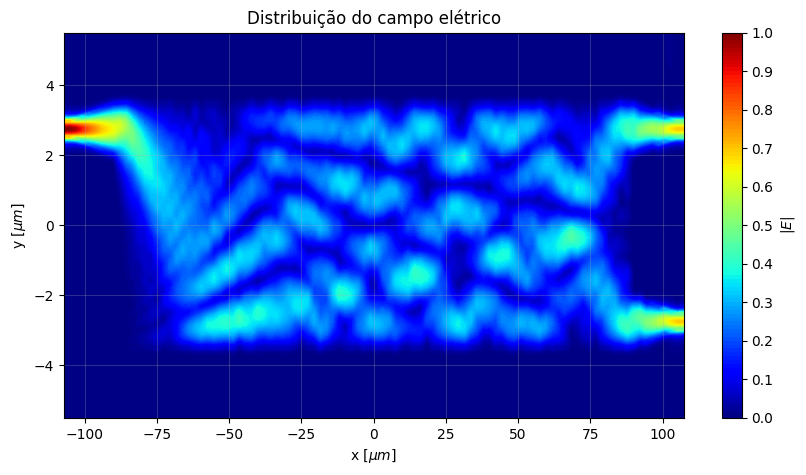

In [92]:
plt.figure(figsize=(10,5))

v = np.linspace(0, 1, 101)

plt.contourf(x,y,np.transpose(E[:,:,0]), v, cmap = plt.get_cmap('jet'))
plt.colorbar(ticks = np.linspace(0, 1, 11), label = r'$|E|$')

plt.title('Distribuição do campo elétrico')
plt.ylabel(r'y [$\mu m$]')
plt.xlabel(r'x [$\mu m$]')
plt.grid(True, alpha = 0.25)

plt.show()

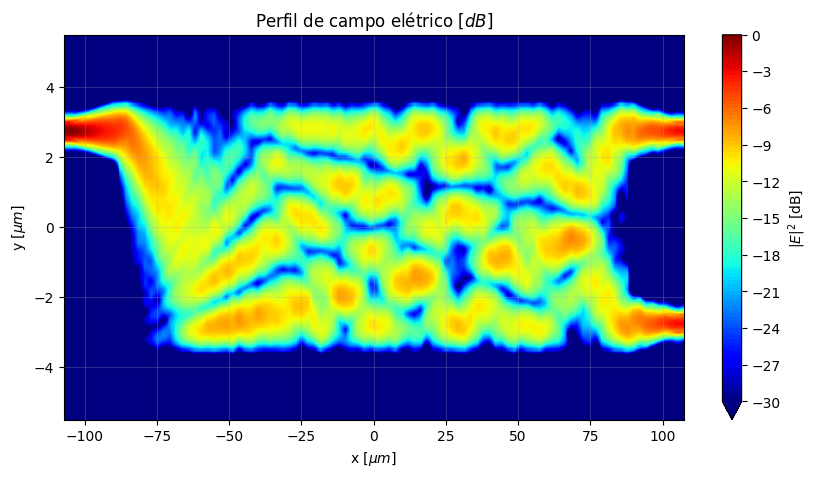

In [93]:
E2 = np.power(E[:,:,0],2)
E2_dB = 10*np.log10(E2/np.max(E2))

v_dB = np.linspace(-30, 0, 101)

plt.figure(figsize=(10,5))
plt.contourf(x,y,np.transpose(E2_dB), v_dB, cmap = plt.get_cmap('jet'), extend = 'min')
plt.colorbar(ticks = np.linspace(-30, 0, 11), label = r'$|E|^2$ [dB]')

plt.title('Perfil de campo elétrico [$dB$]')
plt.ylabel(r'y [$\mu m$]')
plt.xlabel(r'x [$\mu m$]')
plt.grid(True, alpha = 0.25)

plt.show()

In [94]:
modeApi.setemeanalysis('wavelength sweep', 1)
modeApi.setemeanalysis('start wavelength', start_wavelength)
modeApi.setemeanalysis('stop wavelength', stop_wavelength)
modeApi.setemeanalysis('number of wavelength points', 11)
modeApi.setemeanalysis('calculate group delays', 1)

In [95]:
modeApi.emesweep('wavelength sweep')
S = modeApi.getemesweep('S_wavelength_sweep')
wavelength_array = S['wavelength']

T1 = np.abs(S['s11'])**2
T2 = np.abs(S['s31'])**2 # In the S-matrix index mapping, the second port stay in index 3, for some reason
T3 = np.abs(S['s21'])**2 # The third port stay in index 2
T4 = np.abs(S['s41'])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

Text(0.5, 1.0, 'Transmitância [$dB$] x Comprimento de onda')

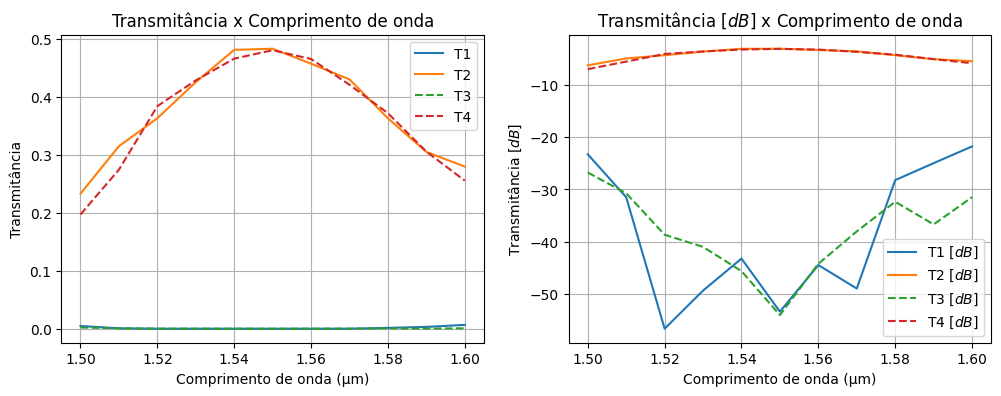

In [96]:
fig4, axs4 = plt.subplots(1, 2, figsize=(12, 4))

axs4[0].plot(wavelength_array/um, T1, label='T1', linewidth=1.5)
axs4[0].plot(wavelength_array/um, T2, label='T2', linewidth=1.5)
axs4[0].plot(wavelength_array/um, T3, label='T3', linewidth=1.5, linestyle='--')
axs4[0].plot(wavelength_array/um, T4, label='T4', linewidth=1.5, linestyle='--')
axs4[0].legend(loc='best')
axs4[0].grid()
axs4[0].set_xlabel('Comprimento de onda (\u03BCm)')
axs4[0].set_ylabel('Transmitância')
axs4[0].set_title('Transmitância x Comprimento de onda')

axs4[1].plot(wavelength_array/um, T1_dB, label = 'T1 [$dB$]', linewidth = 1.5)
axs4[1].plot(wavelength_array/um, T2_dB, label='T2 [$dB$]', linewidth=1.5)
axs4[1].plot(wavelength_array/um, T3_dB, label='T3 [$dB$]', linewidth=1.5, linestyle = '--')
axs4[1].plot(wavelength_array/um, T4_dB, label='T4 [$dB$]', linewidth=1.5, linestyle = '--')
axs4[1].legend(loc='best')
axs4[1].grid()
axs4[1].set_xlabel('Comprimento de onda (\u03BCm)')
axs4[1].set_ylabel('Transmitância [$dB$]')
#axs4[1].set_ylim([0,0.5])
axs4[1].set_title('Transmitância [$dB$] x Comprimento de onda')

In [97]:
total_transmission = T2 + T4
toytal_transmission_dB = 10*np.log10(total_transmission)

Text(0.5, 1.0, 'Transmissão total [$dB$] x Comprimento de onda')

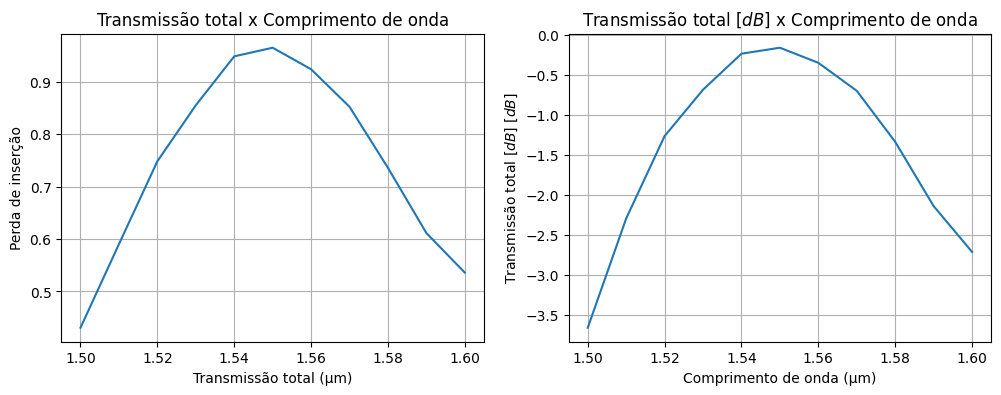

In [98]:
fig5, axs5 = plt.subplots(1, 2, figsize=(12, 4))

axs5[0].plot(wavelength_array/um, total_transmission, linewidth=1.5)
axs5[0].grid(True)
axs5[0].set_xlabel('Transmissão total (\u03BCm)')
axs5[0].set_ylabel('Perda de inserção')
axs5[0].set_title('Transmissão total x Comprimento de onda')

axs5[1].plot(wavelength_array/um, toytal_transmission_dB, linewidth = 1.5)
axs5[1].grid(True)
axs5[1].set_xlabel('Comprimento de onda (\u03BCm)')
axs5[1].set_ylabel(r'Transmissão total [$dB$] [$dB$]')
axs5[1].set_title(r'Transmissão total [$dB$] x Comprimento de onda')

In [99]:
#phase shift
phi2 = np.angle(S['s31'])
phi4 = np.angle(S['s41'])

phase = (phi2 - phi4)*(180/np.pi)

for p in range(0,len(phase),1):
    if(abs(phase[p]) > 180):
        phase[p] = 360-np.abs(phase[p])

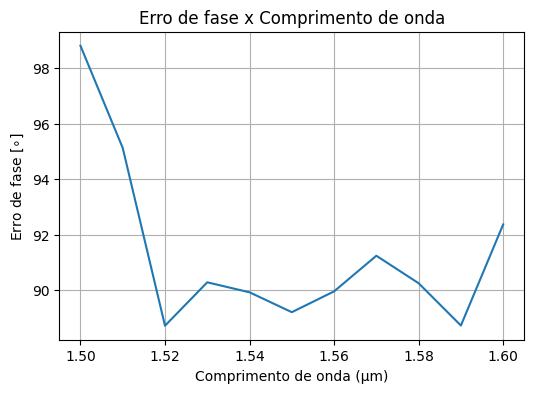

In [100]:
fig = plt.figure(figsize=(6, 4))

plt.plot(wavelength_array/um, phase, linewidth=1.5)
plt.grid(True)
plt.xlabel('Comprimento de onda (\u03BCm)')
plt.ylabel(r'Erro de fase [$\circ$]')
plt.title(r'Erro de fase x Comprimento de onda')

plt.show()

In [101]:
modeApi.close()